In [1]:
import pandas as pd
stats_df = pd.read_csv("intermittedly.csv")

# add bathymetry stats

In [2]:
import os
import xarray as xr
import pandas as pd

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

latlon = stats_df[["lat", "lon"]]
# if you want unique lat/lon pairs:
unique_latlon = latlon.drop_duplicates().to_numpy()

In [3]:
import numpy as np
import xarray as xr

def compute_slope_aspect(ds, var="elevation"):
    
    z = ds[var]

    # grid spacing in degrees
    dlat = float(abs(ds.lat.diff("lat").mean()))
    dlon = float(abs(ds.lon.diff("lon").mean()))

    # convert degrees → meters
    R = 6371000  # Earth radius
    lat_rad = np.deg2rad(ds.lat)

    dy = dlat * np.pi/180 * R
    dx = dlon * np.pi/180 * R * np.cos(lat_rad)

    # compute gradients
    dz_dlat = z.differentiate("lat") / dy
    dz_dlon = z.differentiate("lon") / dx

    # slope (radians → degrees)
    slope = np.arctan(np.sqrt(dz_dlat**2 + dz_dlon**2))
    slope_deg = np.rad2deg(slope)

    # aspect
    aspect = np.arctan2(-dz_dlon, dz_dlat)
    aspect_deg = (np.rad2deg(aspect) + 360) % 360

    return xr.Dataset({
        "slope_deg": slope_deg,
        "aspect_deg": aspect_deg
    })

terrain = compute_slope_aspect(GEBCO_ds)
GEBCO_ds = xr.merge([GEBCO_ds, terrain])

In [4]:
roughness = GEBCO_ds.elevation.rolling(lat=5, lon=5, center=True).std()
GEBCO_ds["roughness"] = roughness

In [5]:
# curvature and curvature in slope direction. pos: convex (ridge), neg: channel
d2z_dx2 = GEBCO_ds.elevation.differentiate("lon").differentiate("lon")
d2z_dy2 = GEBCO_ds.elevation.differentiate("lat").differentiate("lat")

GEBCO_ds["curvature"] = d2z_dx2 + d2z_dy2
GEBCO_ds["profile_curvature"] = d2z_dx2
# BPI value	terrain
#positive	ridge
#negative	valley
#~0	flat
def compute_bpi(ds, window=21):
    mean_z = ds.elevation.rolling(
        lat=window,
        lon=window,
        center=True
    ).mean()

    bpi = ds.elevation - mean_z
    return bpi
GEBCO_ds["bpi"] = compute_bpi(GEBCO_ds, window=21)

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:228: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [6]:
bpi = GEBCO_ds["bpi"]

GEBCO_ds["bpi_norm"] = (bpi - bpi.mean()) / bpi.std()

In [7]:
import numpy as np

# choose rounding precision that matches your station coordinate precision
# (e.g. 5 decimals ~ 1 m; 4 decimals ~ 11 m; 3 decimals ~ 111 m)
ROUND = 5

def key_ll(lat, lon, ndp=ROUND):
    return (round(float(lat), ndp), round(float(lon), ndp))

# stats_df must have columns like: ["station", "lat", "lon"] (rename below if different)
station_lookup = {
    key_ll(r.lat, r.lon): r.station
    for r in stats_df.itertuples(index=False)
}

In [8]:
import xarray as xr

sizes = {
    "0.1x0.1": 0.1,
    "0.25x0.25": 0.25,
    "1x1": 1.0,
    "3x3": 3.0,
    "10x10": 10.0
}


def attach_station_meta(tile: xr.Dataset, station_id, station_lat, station_lon):
    # coords (not data_vars) is best: lightweight and preserved through most ops
    tile = tile.assign_coords(
        station_id=station_id,
        station_lat=float(station_lat),
        station_lon=float(station_lon),
    )
    # optional: make station_id a scalar coord dimensionless
    return tile


def extract_square(ds, lat, lon, size_deg, var="elevation"):
    half = size_deg / 2

    lat0, lat1 = lat - half, lat + half
    lon0, lon1 = lon - half, lon + half

    # lat slice direction safe
    lat_slice = slice(lat0, lat1) if ds.lat[0] < ds.lat[-1] else slice(lat1, lat0)
    lon_slice = slice(lon0, lon1)

    return ds.sel(lat=lat_slice, lon=lon_slice)


def tile_one_var(ds, lat, lon, size_deg, var):
    # extract spatial box then keep only the variable (and coords)
    tile = extract_square(ds, lat, lon, size_deg)
    tile = tile.where(tile["ocean"])
    return tile[var].where(tile["ocean"])
    #return tile[[var]]  # dataset with just that data_var

# choose variables that are on (lat, lon)
vars_2d = [
    v for v in GEBCO_ds.data_vars
    if set(GEBCO_ds[v].dims) == {"lat", "lon"}
]

results_by_var = {
    v: {k: [] for k in sizes.keys()}
    for v in vars_2d
}

results_all = {k: [] for k in sizes}

ocean = GEBCO_ds["elevation"] <= -0.5
GEBCO_ocean = GEBCO_ds.where(ocean)   # one-time mask

results_by_var = {v: {k: [] for k in sizes} for v in vars_2d}

for lat, lon in unique_latlon:
    k = key_ll(lat, lon)
    if k not in station_lookup:
        # skip or handle however you want
        print(f"WARNING: no station match for lat/lon={k}")
        station_id = np.nan
    else:
        station_id = station_lookup[k]

    for size_key, size_deg in sizes.items():
        tile_all = extract_square(GEBCO_ocean, lat, lon, size_deg)

        # attach station metadata ONCE per tile
        tile_all = attach_station_meta(tile_all, station_id, lat, lon)

        for v in vars_2d:
            # store a 1-variable Dataset tile, with station coords included
            results_by_var[v][size_key].append(tile_all[[v]])

In [113]:
import numpy as np
import pandas as pd

# vars_2d is your list of variables (lat, lon)
# sizes is your dict {"0.1x0.1": 0.1, ...}

def tile_mean(ds_tile, var):
    """Mean of var over lat/lon, skipping NaNs."""
    da = ds_tile[var]
    return float(da.mean(dim=("lat", "lon"), skipna=True).values)

rows = []

# pick a reference variable to iterate station indices robustly
ref_var = vars_2d[0]

for size_key in sizes.keys():
    n_tiles = len(results_by_var[ref_var][size_key])

    for i in range(n_tiles):
        # use the reference tile to get station metadata
        ref_tile = results_by_var[ref_var][size_key][i]

        station_id = ref_tile.coords.get("station_id", np.nan).values
        station_lat = ref_tile.coords.get("station_lat", np.nan).values
        station_lon = ref_tile.coords.get("station_lon", np.nan).values

        row = {
            "station_id": station_id.item() if hasattr(station_id, "item") else station_id,
            "station_lat": float(station_lat) if station_lat is not np.nan else np.nan,
            "station_lon": float(station_lon) if station_lon is not np.nan else np.nan,
            "tile_size": size_key,
        }

        # compute mean for every variable at this station/size
        for v in vars_2d:
            ds_tile_v = results_by_var[v][size_key][i]
            # ds_tile_v is a 1-var Dataset (tile_all[[v]])
            row[f"{v}_mean"] = tile_mean(ds_tile_v, v)

        rows.append(row)

summary_df = pd.DataFrame(rows)

# optional: sort for readability
summary_df = summary_df.sort_values(["station_id", "tile_size"]).reset_index(drop=True)

summary_df

,station_id,station_lat,station_lon,tile_size,elevation_mean,slope_deg_mean,aspect_deg_mean,roughness_mean,curvature_mean,profile_curvature_mean,bpi_mean,bpi_norm_mean
0,1,48.3830,-4.49500,0.1x0.1,-13.740157,61.035486,173.925963,9.491281,196157.480315,62475.590551,-20.526354,-0.388717
1,1,48.3830,-4.49500,0.25x0.25,-12.446890,61.044261,172.021293,12.423967,332123.253589,101323.636364,-23.060662,-0.436714
2,1,48.3830,-4.49500,10x10,-304.243347,34.910214,151.473124,7.741590,8372.006144,2619.476426,-0.825029,-0.015597
3,1,48.3830,-4.49500,1x1,-55.265434,42.979269,183.835103,4.224605,45676.310094,12531.683078,-3.557425,-0.067346
4,1,48.3830,-4.49500,3x3,-108.616737,27.533765,152.696764,3.298429,5274.688062,1661.822755,-0.496853,-0.009382
...,...,...,...,...,...,...,...,...,...,...,...,...
1390,578,58.4333,-3.08333,0.1x0.1,-32.789684,67.408912,84.834487,10.425775,228685.714286,118800.000000,-7.806356,-0.147815
1391,578,58.4333,-3.08333,0.25x0.25,-51.928669,57.948872,109.750393,5.169492,74528.395062,32941.563786,-7.212111,-0.136561
1392,578,58.4333,-3.08333,10x10,-384.330444,51.186807,166.562673,5.822960,15705.974122,5251.439885,-1.437148,-0.027190
1393,578,58.4333,-3.08333,1x1,-55.910301,43.471177,139.547649,3.762237,40868.081231,13441.398780,-3.805594,-0.072046


In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def unit_vec_from_bearing(bearing_deg):
    th = np.deg2rad(bearing_deg)
    return np.sin(th), np.cos(th)  # east, north

def find_tile_for_station(results_by_var, bathy_var, size_key, station_id):
    for ds_tile in results_by_var[bathy_var][size_key]:
        sid = ds_tile.coords.get("station_id", None)
        if sid is None:
            continue
        sid = sid.values
        sid = sid.item() if hasattr(sid, "item") else sid
        if sid == station_id:
            return ds_tile
    return None

def format_stat_value(v):
    if pd.isna(v):
        return "NA"
    if isinstance(v, (int, np.integer)):
        return f"{v}"
    if isinstance(v, (float, np.floating)):
        av = abs(v)
        if av >= 1000:
            return f"{v:,.0f}"
        elif av >= 100:
            return f"{v:.1f}"
        elif av >= 1:
            return f"{v:.2f}"
        elif av >= 0.01:
            return f"{v:.3f}"
        else:
            return f"{v:.2e}"
    return str(v)

def make_annotation_lines(row, columns, n_text_cols=2):
    entries = []
    for c in columns:
        if c in row.index:
            entries.append(f"{c}: {format_stat_value(row[c])}")

    if len(entries) == 0:
        return ["No stats"]

    # split into text columns
    chunks = [[] for _ in range(n_text_cols)]
    for i, txt in enumerate(entries):
        chunks[i % n_text_cols].append(txt)

    chunk_text = ["\n".join(ch) for ch in chunks if len(ch) > 0]
    return chunk_text

def plot_tile_comparison(
    summary_df,
    results_by_var,
    station_ids=None,
    size_key="1x1",
    bathy_var="elevation",
    wind_col="wind_dir_mean",
    wave_col="mwd_mean",
    convert_wind_to_from=True,
    convert_wave_to_from=False,
    stats_to_show=None,
    ncols=3,
    max_panels=6,
    land_thresh=-0.5,
    annotation_text_cols=2,
):
    if stats_to_show is None:
        stats_to_show = [
            "station_lat",
            "station_lon",
            "elevation_mean",
            "swh_mean",
            "mwp_mean",
            "tp_mean",
            "mwd_mean",
            "wind_dir_mean",
            "u10_mean",
            "v10_mean",
            "u10_abs_mean",
            "v10_abs_mean",
            "sp_mean",
            "msl_mean",
            "tau_v_mean",
            "wind_wave_alignment_mean",
        ]

    sdf = summary_df[summary_df["tile_size"] == size_key].copy()
    if sdf.empty:
        raise ValueError(f"No rows in summary_df for tile_size={size_key}")

    if station_ids is None:
        station_ids = sdf["station_id"].drop_duplicates().tolist()[:max_panels]
    else:
        station_ids = list(station_ids)[:max_panels]

    panels = []
    for sid in station_ids:
        row = sdf[sdf["station_id"] == sid]
        if row.empty:
            print(f"Skipping station {sid}: no summary row for size {size_key}")
            continue

        row = row.iloc[0]
        tile = find_tile_for_station(results_by_var, bathy_var, size_key, sid)

        if tile is None:
            print(f"Skipping station {sid}: no {bathy_var} tile found")
            continue

        if tile.sizes.get("lat", 0) == 0 or tile.sizes.get("lon", 0) == 0:
            print(f"Skipping station {sid}: empty tile")
            continue

        panels.append((sid, row, tile))

    if len(panels) == 0:
        raise ValueError("No valid stations to plot")

    n = len(panels)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows), squeeze=False)
    axes = axes.ravel()

    pcm = None

    for ax in axes[n:]:
        ax.axis("off")

    for ax, (sid, row, tile) in zip(axes, panels):
        try:
            z = tile[bathy_var]
            if bathy_var == "elevation":
                z = z.where(z <= land_thresh)

            lon_vals = tile["lon"].values
            lat_vals = tile["lat"].values

            if lon_vals.size == 0 or lat_vals.size == 0:
                ax.axis("off")
                ax.set_title(f"{sid}\nempty tile")
                continue

            lon_min = float(np.nanmin(lon_vals))
            lon_max = float(np.nanmax(lon_vals))
            lat_min = float(np.nanmin(lat_vals))
            lat_max = float(np.nanmax(lat_vals))

            dlon = lon_max - lon_min
            dlat = lat_max - lat_min
            if dlon <= 0 or dlat <= 0:
                ax.axis("off")
                ax.set_title(f"{sid}\ninvalid extent")
                continue

            pcm = ax.pcolormesh(tile["lon"], tile["lat"], z, shading="auto")

            # station
            slat = float(row["station_lat"])
            slon = float(row["station_lon"])
            ax.plot(slon, slat, "ro", ms=6, zorder=5)

            # arrows
            L = 0.20 * min(dlon, dlat)
            head_w = 0.03 * min(dlon, dlat)
            head_l = 0.045 * min(dlon, dlat)

            wind_dir = row[wind_col] if wind_col in row.index else np.nan
            if pd.notna(wind_dir):
                wind_dir = float(wind_dir)
                if convert_wind_to_from:
                    wind_dir = (wind_dir + 180.0) % 360.0
                ux, uy = unit_vec_from_bearing(wind_dir)
                ax.arrow(
                    slon, slat, L * ux, L * uy,
                    color="deepskyblue",
                    linewidth=2,
                    length_includes_head=True,
                    head_width=head_w,
                    head_length=head_l,
                    zorder=6
                )

            wave_dir = row[wave_col] if wave_col in row.index else np.nan
            if pd.notna(wave_dir):
                wave_dir = float(wave_dir)
                if convert_wave_to_from:
                    wave_dir = (wave_dir + 180.0) % 360.0
                ux, uy = unit_vec_from_bearing(wave_dir)
                ax.arrow(
                    slon, slat, L * ux, L * uy,
                    color="orange",
                    linewidth=2,
                    length_includes_head=True,
                    head_width=head_w,
                    head_length=head_l,
                    zorder=6
                )

            # annotation blocks
            text_blocks = make_annotation_lines(row, stats_to_show, n_text_cols=annotation_text_cols)

            x_positions = [0.02, 0.52] if annotation_text_cols == 2 else [0.02]
            for i, block in enumerate(text_blocks):
                xloc = x_positions[i] if i < len(x_positions) else 0.02 + i * 0.25
                ax.text(
                    xloc, 0.98,
                    block,
                    transform=ax.transAxes,
                    va="top", ha="left",
                    fontsize=8.5,
                    family="monospace",
                    bbox=dict(boxstyle="round", facecolor="white", alpha=0.82)
                )

            ax.set_title(f"Station {sid} | {size_key}")
            ax.set_xlim(lon_min, lon_max)
            ax.set_ylim(lat_min, lat_max)
            ax.set_xlabel("lon")
            ax.set_ylabel("lat")

        except Exception as e:
            ax.axis("off")
            ax.set_title(f"{sid}\nskipped")
            print(f"Skipping station {sid}: {e}")

    if pcm is not None:
        cbar = fig.colorbar(pcm, ax=axes[:n], shrink=0.9)
        cbar.set_label(bathy_var)

    plt.tight_layout()
    plt.show()

In [120]:
results_by_var["elevation_mean"]

KeyError: 'elevation_mean'

In [115]:
summary_df.aspect_deg_mean

0       173.925963
1       172.021293
2       151.473124
3       183.835103
4       152.696764
           ...    
1390     84.834487
1391    109.750393
1392    166.562673
1393    139.547649
1394    148.767108
Name: aspect_deg_mean, Length: 1395, dtype: float64

Skipping station 9: empty tile
Skipping station 10: empty tile
Skipping station 11: empty tile


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76809/261460040.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


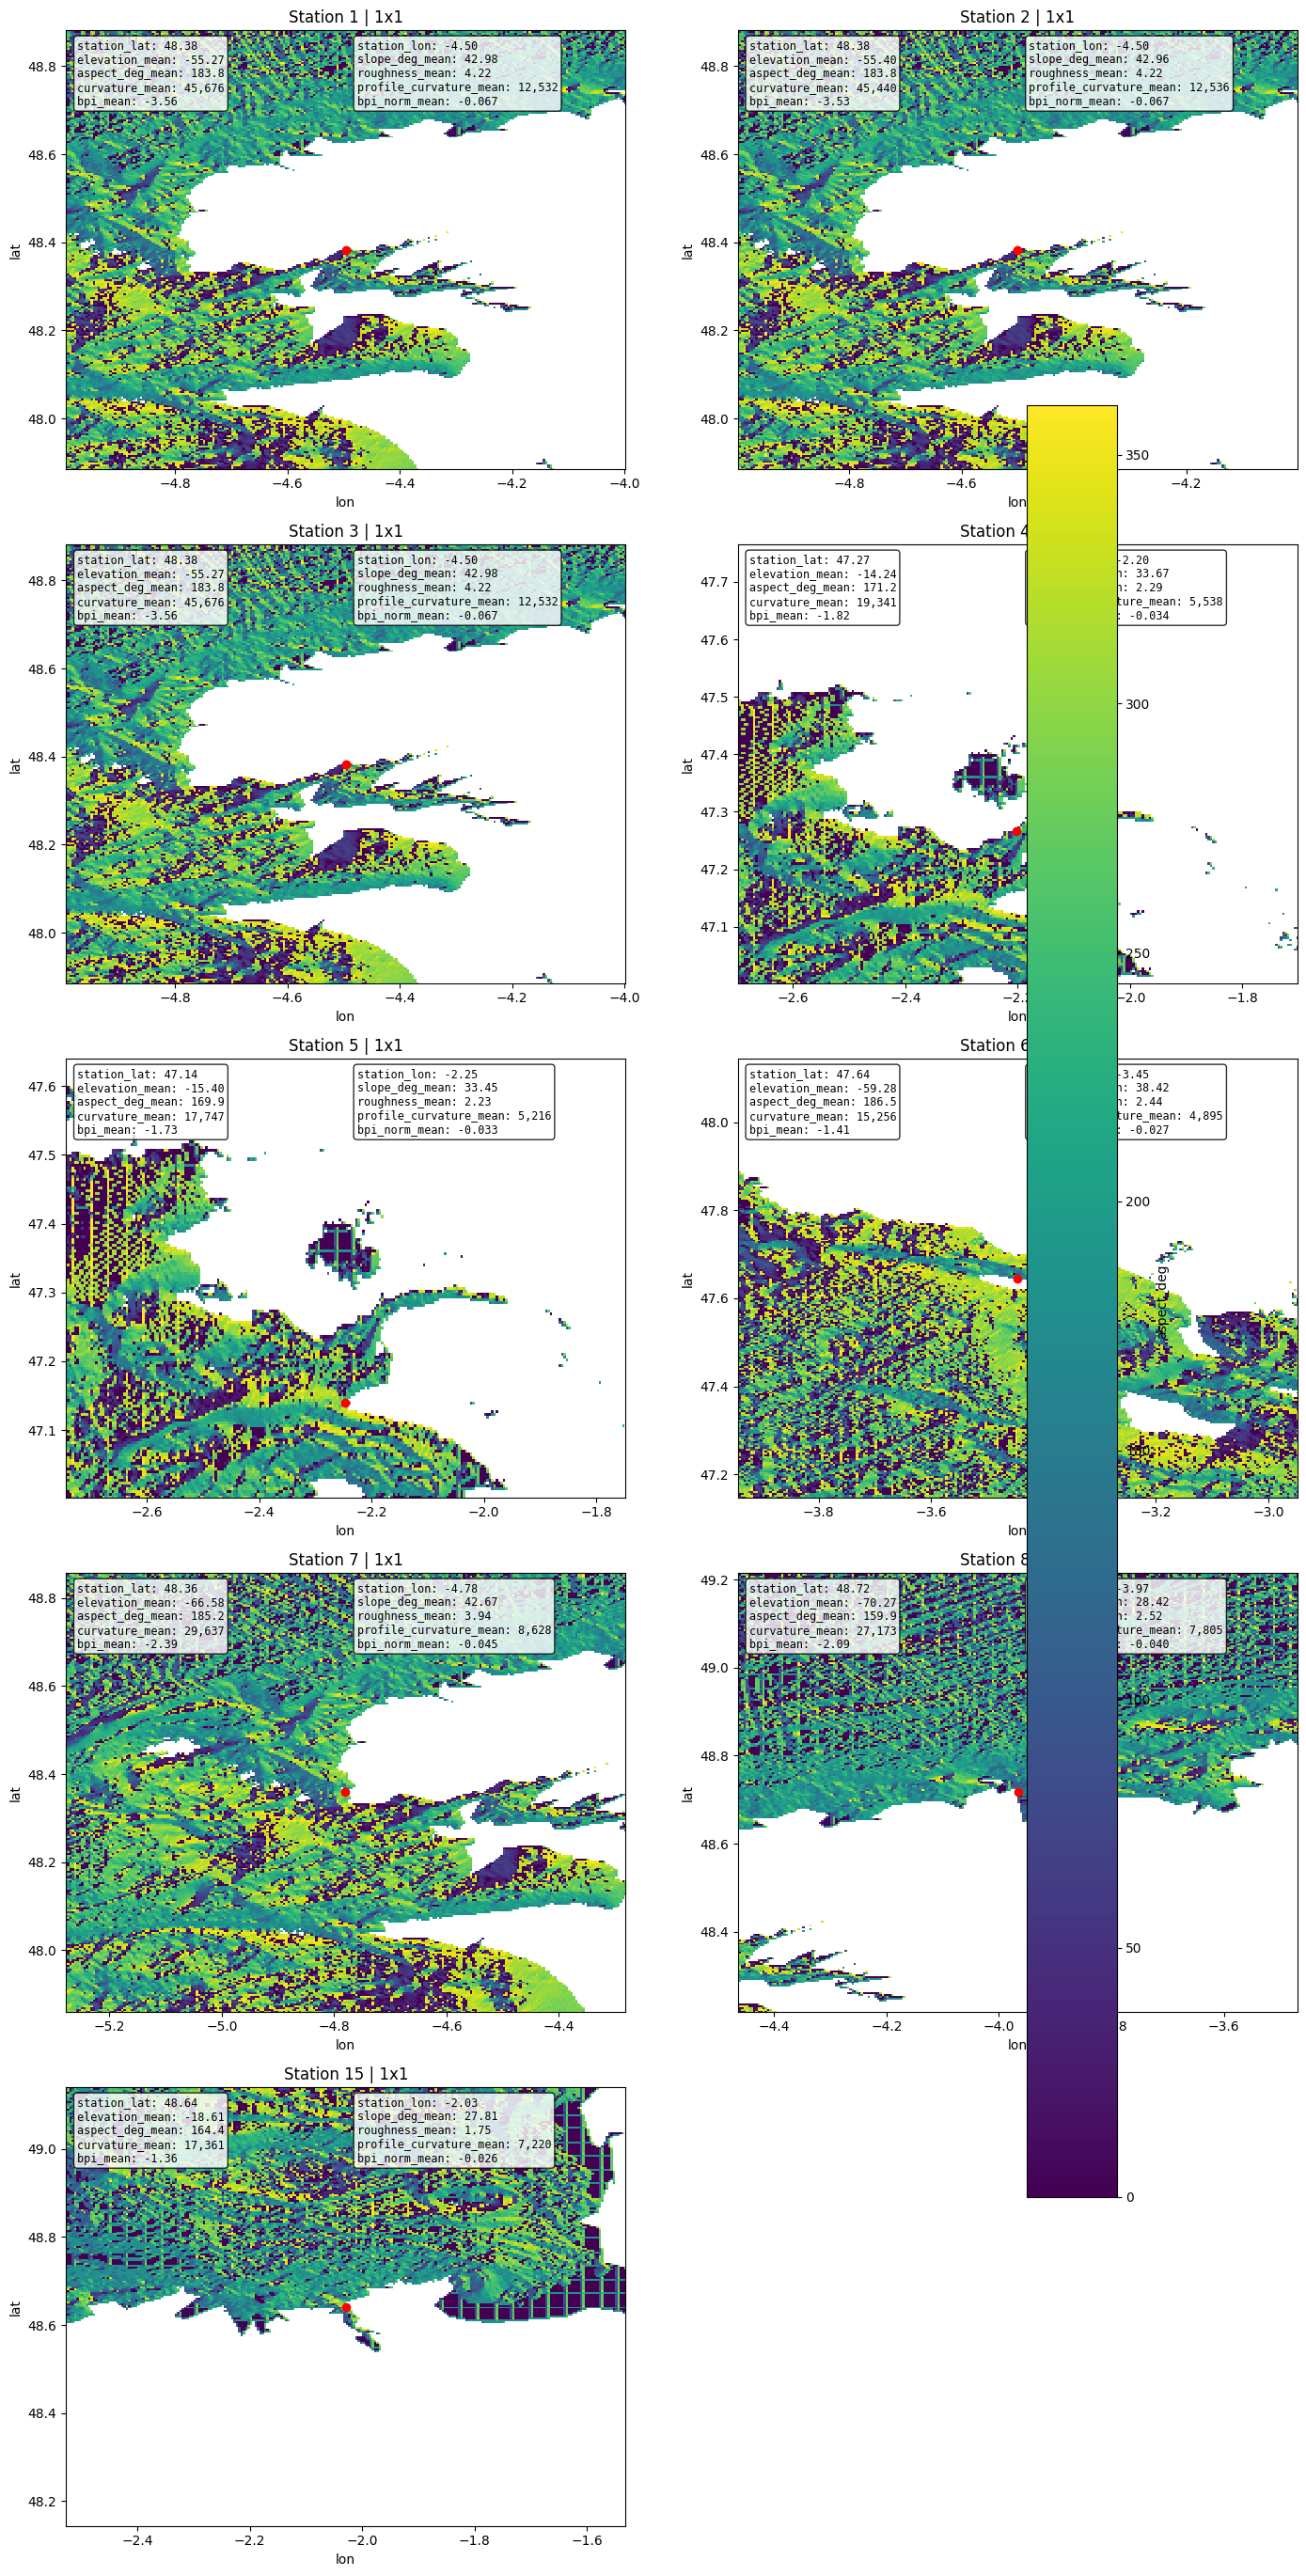

In [124]:
plot_tile_comparison(
    summary_df=summary_df,
    results_by_var=results_by_var,
    size_key="1x1",
   # bathy_var="elevation",
   bathy_var="aspect_deg",
    wind_col="wind_dir_mean",
    wave_col="mwd_mean",
    convert_wind_to_from=True,
    convert_wave_to_from=False,
    stats_to_show=[
        "station_lat",
        "station_lon",
        "elevation_mean", 'slope_deg_mean', 'aspect_deg_mean', 'roughness_mean',
       'curvature_mean', 'profile_curvature_mean', 'bpi_mean',
       'bpi_norm_mean'
    ],
    ncols=2,
    max_panels=12,
    annotation_text_cols=2,
)

Skipping station 9: empty tile
Skipping station 10: empty tile
Skipping station 11: empty tile


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_76809/261460040.py:237: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


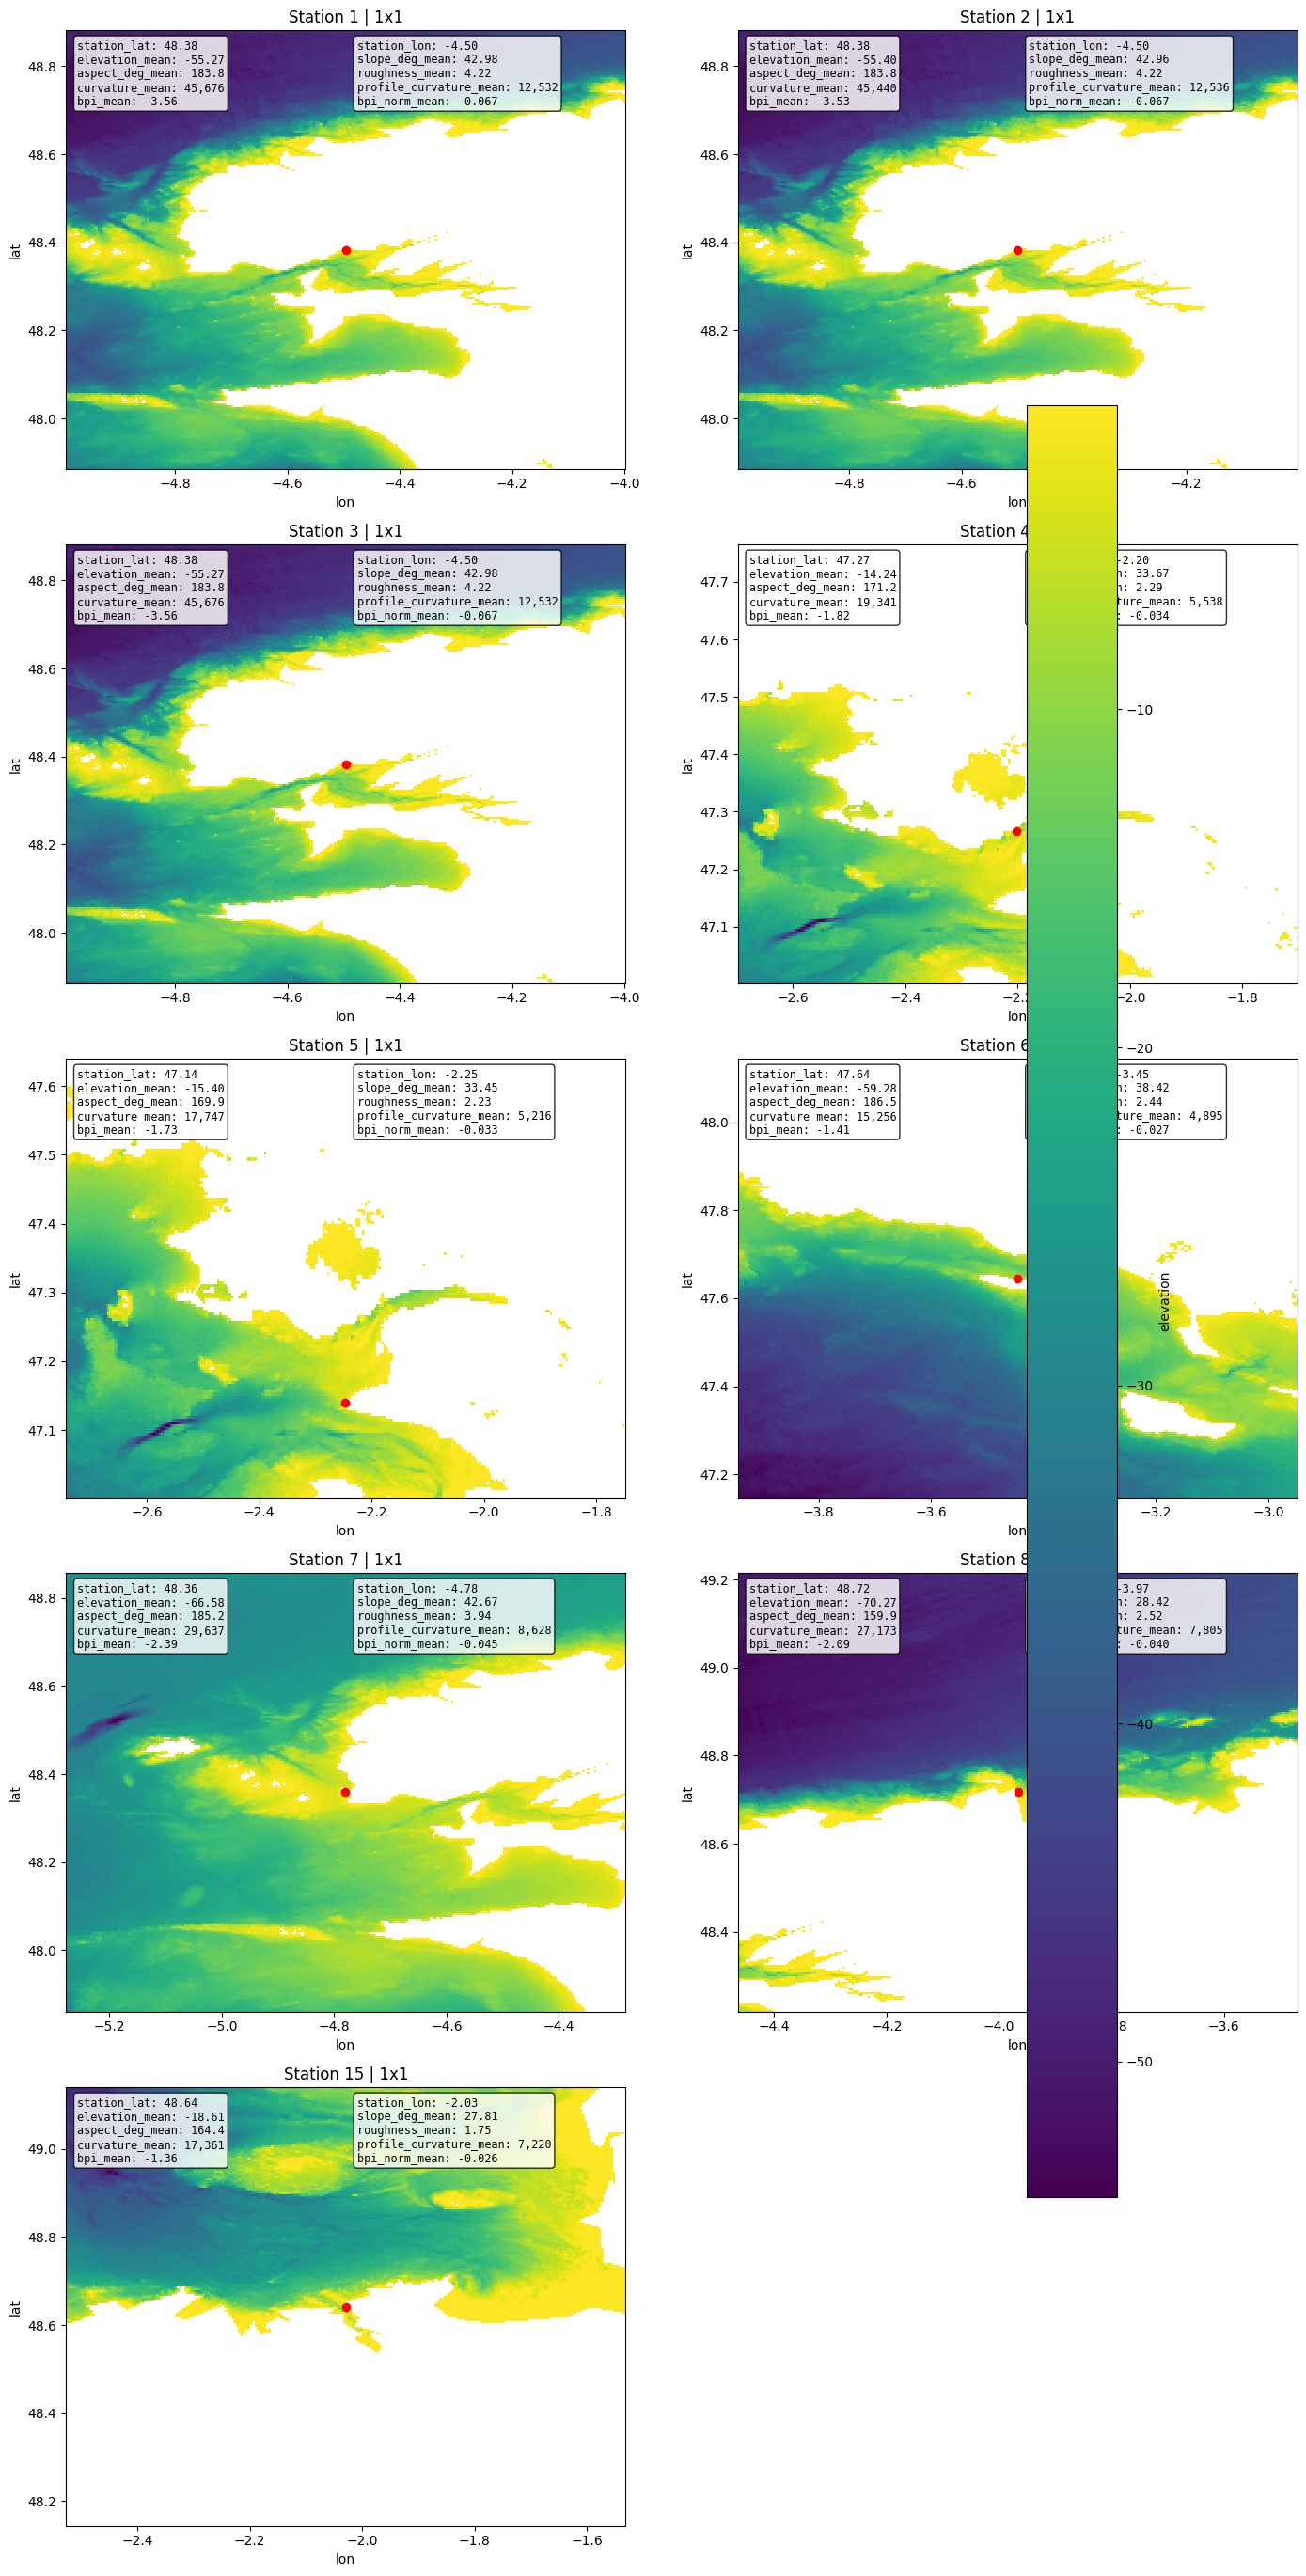

In [125]:
plot_tile_comparison(
    summary_df=summary_df,
    results_by_var=results_by_var,
    size_key="1x1",
   # bathy_var="elevation",
   bathy_var="elevation",
    wind_col="wind_dir_mean",
    wave_col="mwd_mean",
    convert_wind_to_from=True,
    convert_wave_to_from=False,
    stats_to_show=[
        "station_lat",
        "station_lon",
        "elevation_mean", 'slope_deg_mean', 'aspect_deg_mean', 'roughness_mean',
       'curvature_mean', 'profile_curvature_mean', 'bpi_mean',
       'bpi_norm_mean'
    ],
    ncols=2,
    max_panels=12,
    annotation_text_cols=2,
)

In [129]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

R = 6371000.0

def latlon_to_xy_m(lat, lon, lat0, lon0):
    x = np.deg2rad(lon - lon0) * R * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat - lat0) * R
    return x, y

def xy_to_bearing_deg(x, y):
    # bearing clockwise from north
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def bearing_station_to_target(station_lat, station_lon, target_lat, target_lon):
    x, y = latlon_to_xy_m(target_lat, target_lon, station_lat, station_lon)
    return xy_to_bearing_deg(x, y)
# deepest fraction of water cells and computes a depth-weighted centroid
def deep_water_centroid(tile, land_thresh=-0.5, deepest_quantile=0.10):
    z = tile["elevation"].values
    lats = tile["lat"].values
    lons = tile["lon"].values

    lat2d, lon2d = np.meshgrid(lats, lons, indexing="ij")

    water = np.isfinite(z) & (z <= land_thresh)
    if not np.any(water):
        raise ValueError("No water cells in tile")

    depth = -z  # positive depth
    water_depths = depth[water]

    thresh = np.quantile(water_depths, 1 - deepest_quantile)
    deep_mask = water & (depth >= thresh)

    if not np.any(deep_mask):
        raise ValueError("No deep-water cells selected")

    w = depth[deep_mask]
    lat_c = np.sum(lat2d[deep_mask] * w) / np.sum(w)
    lon_c = np.sum(lon2d[deep_mask] * w) / np.sum(w)

    return lat_c, lon_c, deep_mask

def corridor_profile_to_target(tile, station_lat, station_lon, target_lat, target_lon,
                               corridor_width_km=10.0, land_thresh=-0.5):
    z = tile["elevation"].values
    lats = tile["lat"].values
    lons = tile["lon"].values
    lat2d, lon2d = np.meshgrid(lats, lons, indexing="ij")

    water = np.isfinite(z) & (z <= land_thresh)
    if not np.any(water):
        raise ValueError("No water cells in tile")

    # coordinates relative to station
    x, y = latlon_to_xy_m(lat2d, lon2d, station_lat, station_lon)

    # target vector
    xt, yt = latlon_to_xy_m(target_lat, target_lon, station_lat, station_lon)
    L = np.hypot(xt, yt)
    if L == 0:
        raise ValueError("Target coincides with station")

    ux = xt / L
    uy = yt / L

    # along-track and cross-track
    s = x * ux + y * uy
    c = -x * uy + y * ux

    half_width_m = 0.5 * corridor_width_km * 1000.0

    # keep cells within corridor and between station and target
    mask = water & (np.abs(c) <= half_width_m) & (s >= 0) & (s <= L)

    if not np.any(mask):
        raise ValueError("No water cells inside corridor")

    df = pd.DataFrame({
        "s_m": s[mask],
        "c_m": c[mask],
        "elevation": z[mask]
    })

    return df, L


def corridor_profile_to_target(tile, station_lat, station_lon, target_lat, target_lon,
                               corridor_width_km=10.0, land_thresh=-0.5):
    z = tile["elevation"].values
    lats = tile["lat"].values
    lons = tile["lon"].values
    lat2d, lon2d = np.meshgrid(lats, lons, indexing="ij")

    water = np.isfinite(z) & (z <= land_thresh)
    if not np.any(water):
        raise ValueError("No water cells in tile")

    # coordinates relative to station
    x, y = latlon_to_xy_m(lat2d, lon2d, station_lat, station_lon)

    # target vector
    xt, yt = latlon_to_xy_m(target_lat, target_lon, station_lat, station_lon)
    L = np.hypot(xt, yt)
    if L == 0:
        raise ValueError("Target coincides with station")

    ux = xt / L
    uy = yt / L

    # along-track and cross-track
    s = x * ux + y * uy
    c = -x * uy + y * ux

    half_width_m = 0.5 * corridor_width_km * 1000.0

    # keep cells within corridor and between station and target
    mask = water & (np.abs(c) <= half_width_m) & (s >= 0) & (s <= L)

    if not np.any(mask):
        raise ValueError("No water cells inside corridor")

    df = pd.DataFrame({
        "s_m": s[mask],
        "c_m": c[mask],
        "elevation": z[mask]
    })

    return df, L

def slope_from_profile(profile_df):
    df = profile_df[np.isfinite(profile_df["distance_m"]) & np.isfinite(profile_df["elevation_mean"])].copy()

    if len(df) < 2:
        return {
            "slope_mpm": np.nan,
            "slope_deg": np.nan,
            "end_to_end_mpm": np.nan,
            "path_length_m": np.nan
        }

    s = df["distance_m"].values
    z = df["elevation_mean"].values

    lr = linregress(s, z)
    slope_mpm = lr.slope
    end_to_end = (z[-1] - z[0]) / (s[-1] - s[0]) if (s[-1] - s[0]) > 0 else np.nan

    return {
        "slope_mpm": slope_mpm,
        "slope_deg": np.degrees(np.arctan(abs(slope_mpm))),
        "end_to_end_mpm": end_to_end,
        "path_length_m": s[-1] - s[0]
    }
def binned_corridor_profile(df, bin_size_m=1000.0):
    prof = df.copy()
    prof["bin"] = (prof["s_m"] // bin_size_m).astype(int)

    out = (
        prof.groupby("bin")
        .agg(
            distance_m=("s_m", "mean"),
            elevation_mean=("elevation", "mean"),
            elevation_min=("elevation", "min"),
            elevation_max=("elevation", "max"),
            n=("elevation", "size")
        )
        .reset_index(drop=True)
        .sort_values("distance_m")
    )

    return out
def offshore_direction_and_slope(tile, station_lat, station_lon,
                                 deepest_quantile=0.10,
                                 corridor_width_km=10.0,
                                 land_thresh=-0.5,
                                 bin_size_m=1000.0):
    target_lat, target_lon, deep_mask = deep_water_centroid(
        tile,
        land_thresh=land_thresh,
        deepest_quantile=deepest_quantile
    )

    bearing_deg = bearing_station_to_target(
        station_lat, station_lon, target_lat, target_lon
    )

    corridor_df, target_dist_m = corridor_profile_to_target(
        tile,
        station_lat, station_lon,
        target_lat, target_lon,
        corridor_width_km=corridor_width_km,
        land_thresh=land_thresh
    )

    profile_df = binned_corridor_profile(corridor_df, bin_size_m=bin_size_m)
    slope_stats = slope_from_profile(profile_df)

    result = {
        "target_lat": target_lat,
        "target_lon": target_lon,
        "bearing_deg": bearing_deg,
        "target_dist_m": target_dist_m,
        **slope_stats
    }

    return result, profile_df, corridor_df, deep_mask

In [130]:
row = stats_df.iloc[0]
sid = row["station"]
slat = float(row["lat"])
slon = float(row["lon"])

tile = tile_lookup[(sid, "10x10")]

result, profile_df, corridor_df, deep_mask = offshore_direction_and_slope(
    tile,
    slat,
    slon,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    land_thresh=-0.5,
    bin_size_m=1000.0
)

print(result)

{'target_lat': 47.39005214914356, 'target_lon': -8.193228440421228, 'bearing_deg': 247.98816418479998, 'target_dist_m': 294587.29459357925, 'slope_mpm': -0.008820658565598907, 'slope_deg': 0.5053734019129851, 'end_to_end_mpm': -0.008647565189559923, 'path_length_m': 293779.26458004076}


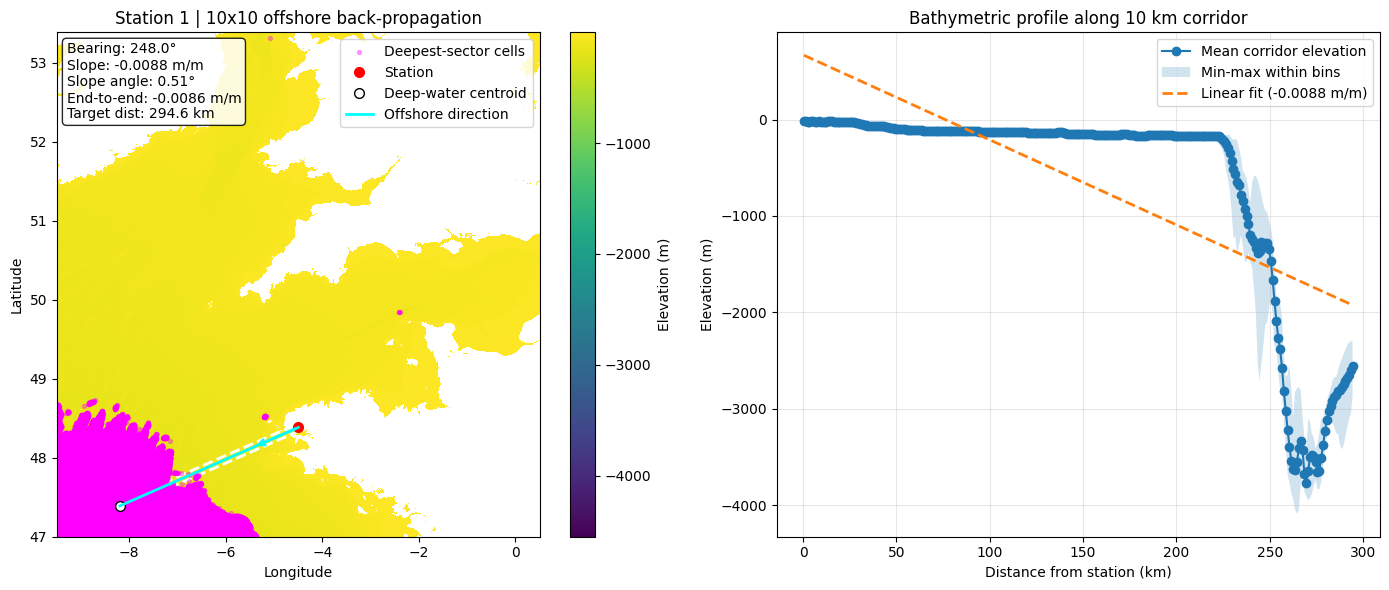

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

R = 6371000.0

def latlon_to_xy_m(lat, lon, lat0, lon0):
    x = np.deg2rad(lon - lon0) * R * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat - lat0) * R
    return x, y

def xy_m_to_latlon(x, y, lat0, lon0):
    lat = lat0 + np.rad2deg(y / R)
    lon = lon0 + np.rad2deg(x / (R * np.cos(np.deg2rad(lat0))))
    return lat, lon

def plot_offshore_direction_and_slope(
    tile,
    station_lat,
    station_lon,
    result,
    profile_df,
    corridor_df,
    deep_mask,
    corridor_width_km=10.0,
    land_thresh=-0.5,
    title=None,
):
    z = tile["elevation"].values
    lats = tile["lat"].values
    lons = tile["lon"].values
    lat2d, lon2d = np.meshgrid(lats, lons, indexing="ij")

    # mask land for plotting
    z_plot = np.where(np.isfinite(z) & (z <= land_thresh), z, np.nan)

    target_lat = result["target_lat"]
    target_lon = result["target_lon"]

    # station -> target vector in local xy
    xt, yt = latlon_to_xy_m(target_lat, target_lon, station_lat, station_lon)
    L = np.hypot(xt, yt)
    ux = xt / L
    uy = yt / L

    half_width_m = 0.5 * corridor_width_km * 1000.0

    # corridor polygon corners in local xy
    p0_left  = np.array([0, 0]) + half_width_m * np.array([-uy,  ux])
    p0_right = np.array([0, 0]) - half_width_m * np.array([-uy,  ux])
    p1_left  = np.array([xt, yt]) + half_width_m * np.array([-uy,  ux])
    p1_right = np.array([xt, yt]) - half_width_m * np.array([-uy,  ux])

    # convert polygon to lat/lon
    poly_xy = np.vstack([p0_left, p1_left, p1_right, p0_right])
    poly_latlon = [xy_m_to_latlon(x, y, station_lat, station_lon)[::-1] for x, y in poly_xy]
    # [::-1] because Polygon expects (lon, lat)

    # deep-mask points
    deep_lats = lat2d[deep_mask]
    deep_lons = lon2d[deep_mask]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # -------------------------
    # Left panel: map
    # -------------------------
    ax = axes[0]
    pcm = ax.pcolormesh(tile["lon"], tile["lat"], z_plot, shading="auto")
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")

    # corridor polygon
    poly = Polygon(poly_latlon, closed=True, fill=False, edgecolor="white", linewidth=2, linestyle="--")
    ax.add_patch(poly)

    # deep-water cells
    ax.scatter(deep_lons, deep_lats, s=8, c="magenta", alpha=0.35, label="Deepest-sector cells")

    # station and target
    ax.plot(station_lon, station_lat, "ro", ms=7, label="Station")
    ax.plot(target_lon, target_lat, "wo", ms=7, mec="k", label="Deep-water centroid")

    # main direction line
    ax.plot([station_lon, target_lon], [station_lat, target_lat], color="cyan", lw=2, label="Offshore direction")

    # arrow
    frac = 0.25
    arrow_lon = station_lon + frac * (target_lon - station_lon)
    arrow_lat = station_lat + frac * (target_lat - station_lat)
    ax.annotate(
        "",
        xy=(arrow_lon, arrow_lat),
        xytext=(station_lon, station_lat),
        arrowprops=dict(arrowstyle="->", color="cyan", lw=2),
    )

    txt = (
        f"Bearing: {result['bearing_deg']:.1f}°\n"
        f"Slope: {result['slope_mpm']:.4f} m/m\n"
        f"Slope angle: {result['slope_deg']:.2f}°\n"
        f"End-to-end: {result['end_to_end_mpm']:.4f} m/m\n"
        f"Target dist: {result['target_dist_m']/1000:.1f} km"
    )
    ax.text(
        0.02, 0.98, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or "Offshore direction and 10 km corridor")
    ax.legend(loc="best")

    # -------------------------
    # Right panel: profile
    # -------------------------
    ax2 = axes[1]
    ax2.plot(profile_df["distance_m"] / 1000, profile_df["elevation_mean"], "-o", label="Mean corridor elevation")
    if "elevation_min" in profile_df.columns:
        ax2.fill_between(
            profile_df["distance_m"] / 1000,
            profile_df["elevation_min"],
            profile_df["elevation_max"],
            alpha=0.2,
            label="Min-max within bins",
        )

    # regression line
    finite = np.isfinite(profile_df["distance_m"]) & np.isfinite(profile_df["elevation_mean"])
    if finite.sum() >= 2:
        s = profile_df.loc[finite, "distance_m"].values
        zmean = profile_df.loc[finite, "elevation_mean"].values
        coef = np.polyfit(s, zmean, 1)
        sfit = np.linspace(s.min(), s.max(), 100)
        zfit = coef[0] * sfit + coef[1]
        ax2.plot(sfit / 1000, zfit, "--", lw=2, label=f"Linear fit ({coef[0]:.4f} m/m)")

    ax2.set_xlabel("Distance from station (km)")
    ax2.set_ylabel("Elevation (m)")
    ax2.set_title("Bathymetric profile along 10 km corridor")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()
    
    
row = stats_df.iloc[0]
sid = row["station"]
slat = float(row["lat"])
slon = float(row["lon"])

tile = tile_lookup[(sid, "10x10")]

result, profile_df, corridor_df, deep_mask = offshore_direction_and_slope(
    tile,
    slat,
    slon,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    land_thresh=-0.5,
    bin_size_m=1000.0,
)

plot_offshore_direction_and_slope(
    tile,
    slat,
    slon,
    result,
    profile_df,
    corridor_df,
    deep_mask,
    corridor_width_km=10.0,
    title=f"Station {sid} | 10x10 offshore back-propagation",
)

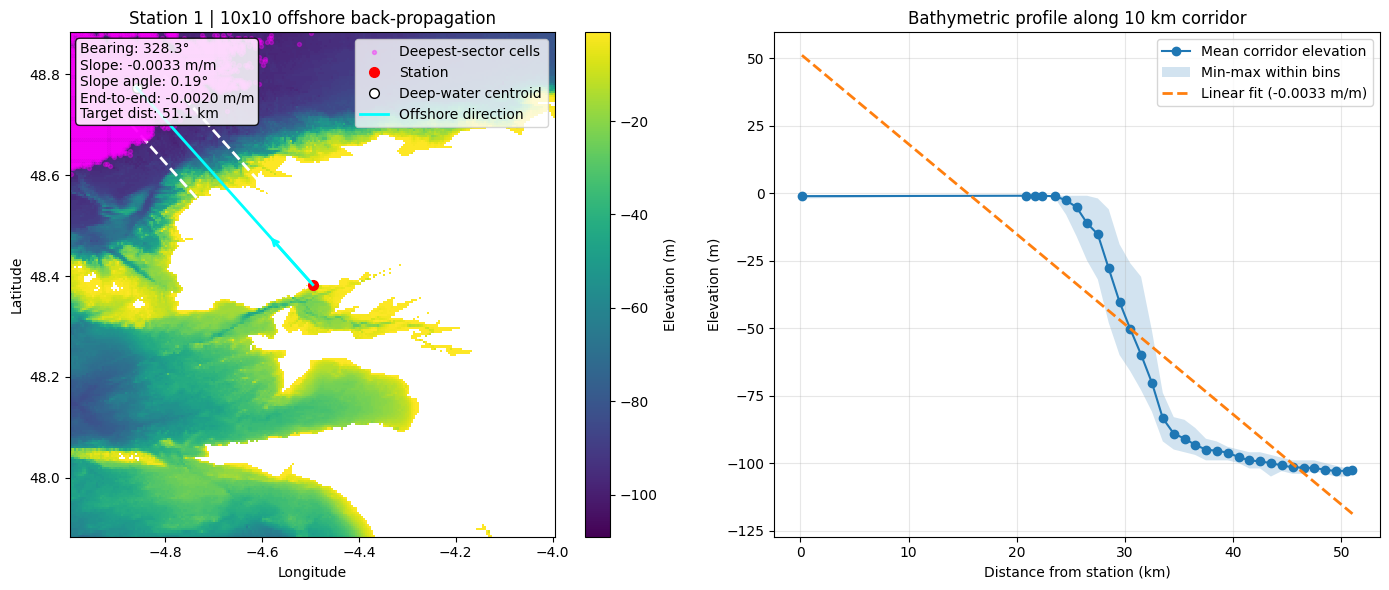

In [133]:
row = stats_df.iloc[0]
sid = row["station"]
slat = float(row["lat"])
slon = float(row["lon"])
tile = tile_lookup[(sid, "1x1")]

result, profile_df, corridor_df, deep_mask = offshore_direction_and_slope(
    tile,
    slat,
    slon,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    land_thresh=-0.5,
    bin_size_m=1000.0,
)

plot_offshore_direction_and_slope(
    tile,
    slat,
    slon,
    result,
    profile_df,
    corridor_df,
    deep_mask,
    corridor_width_km=10.0,
    title=f"Station {sid} | 10x10 offshore back-propagation",
)

In [142]:
import numpy as np
import pandas as pd
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.stats import linregress

R = 6371000.0

def latlon_to_xy_m(lat, lon, lat0, lon0):
    x = np.deg2rad(lon - lon0) * R * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat - lat0) * R
    return x, y

def xy_to_bearing_deg(x, y):
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def cellsize_m(lat_deg, dlat_deg, dlon_deg):
    dy = np.deg2rad(dlat_deg) * R
    dx = np.deg2rad(dlon_deg) * R * np.cos(np.deg2rad(lat_deg))
    return dx, dy

def make_water_mask(tile, land_thresh=-0.5):
    z = tile["elevation"].values
    return np.isfinite(z) & (z <= land_thresh)

def nearest_water_cell(tile, station_lat, station_lon, water_mask):
    lat2d, lon2d = np.meshgrid(tile["lat"].values, tile["lon"].values, indexing="ij")
    x, y = latlon_to_xy_m(lat2d, lon2d, station_lat, station_lon)
    dist2 = x**2 + y**2
    dist2 = np.where(water_mask, dist2, np.inf)

    if not np.isfinite(dist2).any():
        raise ValueError("No reachable water cells in tile")

    return np.unravel_index(np.argmin(dist2), dist2.shape)

def extract_path_from_predecessors(predecessors, start_node, end_node):
    path = [end_node]
    cur = end_node
    while cur != start_node:
        cur = predecessors[cur]
        if cur == -9999:
            return None
        path.append(cur)
    path.reverse()
    return path

def node_to_ij(node, nlon):
    return node // nlon, node % nlon

In [143]:
import numpy as np
import pandas as pd
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.stats import linregress

R = 6371000.0

def latlon_to_xy_m(lat, lon, lat0, lon0):
    x = np.deg2rad(lon - lon0) * R * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat - lat0) * R
    return x, y

def xy_to_bearing_deg(x, y):
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def cellsize_m(lat_deg, dlat_deg, dlon_deg):
    dy = np.deg2rad(dlat_deg) * R
    dx = np.deg2rad(dlon_deg) * R * np.cos(np.deg2rad(lat_deg))
    return dx, dy

def make_water_mask(tile, land_thresh=-0.5):
    z = tile["elevation"].values
    return np.isfinite(z) & (z <= land_thresh)

def nearest_water_cell(tile, station_lat, station_lon, water_mask):
    lat2d, lon2d = np.meshgrid(tile["lat"].values, tile["lon"].values, indexing="ij")
    x, y = latlon_to_xy_m(lat2d, lon2d, station_lat, station_lon)
    dist2 = x**2 + y**2
    dist2 = np.where(water_mask, dist2, np.inf)

    if not np.isfinite(dist2).any():
        raise ValueError("No reachable water cells in tile")

    return np.unravel_index(np.argmin(dist2), dist2.shape)

def extract_path_from_predecessors(predecessors, start_node, end_node):
    path = [end_node]
    cur = end_node
    while cur != start_node:
        cur = predecessors[cur]
        if cur == -9999:
            return None
        path.append(cur)
    path.reverse()
    return path

def node_to_ij(node, nlon):
    return node // nlon, node % nlon

In [145]:
def build_water_graph_to_depth(tile, water_mask, depth_weight=2.0, distance_weight=1.0):
    """
    Lower cost for moving into deeper water.
    """
    lats = tile["lat"].values
    lons = tile["lon"].values
    z = tile["elevation"].values  # negative in water

    nlat, nlon = water_mask.shape
    N = nlat * nlon
    G = lil_matrix((N, N), dtype=float)

    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 ( 0, -1),          ( 0, 1),
                 ( 1, -1), ( 1, 0), ( 1, 1)]

    dlat = float(np.abs(np.diff(lats).mean()))
    dlon = float(np.abs(np.diff(lons).mean()))
    lat_ascending = lats[-1] > lats[0]

    def node_id(i, j):
        return i * nlon + j

    for i in range(nlat):
        dx, dy = cellsize_m(lats[i], dlat, dlon)

        for j in range(nlon):
            if not water_mask[i, j]:
                continue

            u = node_id(i, j)

            for di, dj in neighbors:
                ii, jj = i + di, j + dj
                if ii < 0 or ii >= nlat or jj < 0 or jj >= nlon:
                    continue
                if not water_mask[ii, jj]:
                    continue

                step_e = dj * dx
                step_n = di * dy if lat_ascending else -di * dy
                step_len = np.hypot(step_e, step_n)
                if step_len == 0:
                    continue

                # reward deeper destination cells
                depth_pos = max(-z[ii, jj], 0.0)  # positive depth
                depth_bonus = depth_weight * np.log1p(depth_pos)

                # keep cost positive
                cost = distance_weight * step_len / (1.0 + depth_bonus)

                v = node_id(ii, jj)
                G[u, v] = cost

    return G.tocsr()

In [181]:
import numpy as np
import xarray as xr

def coarsen_tile_to_target_points(tile, target_n_points=1000, land_thresh=-0.5):
    """
    Coarsen a tile so total grid cells are roughly target_n_points.
    Bathymetry is averaged over water only; all-land coarse cells become NaN.

    Returns
    -------
    tile_c : xr.Dataset
        Coarsened tile
    meta : dict
        Information about original/coarsened sizes and factors
    """
    nlat = tile.sizes.get("lat", 0)
    nlon = tile.sizes.get("lon", 0)

    if nlat == 0 or nlon == 0:
        raise ValueError("Tile has empty lat/lon dimension")

    n_total = nlat * nlon
    if n_total <= target_n_points:
        return tile.copy(), {
            "coarsen_factor_lat": 1,
            "coarsen_factor_lon": 1,
            "original_nlat": nlat,
            "original_nlon": nlon,
            "coarsened_nlat": nlat,
            "coarsened_nlon": nlon,
            "original_n_points": n_total,
            "coarsened_n_points": n_total,
        }

    # isotropic-ish factor
    factor = int(np.ceil(np.sqrt(n_total / target_n_points)))
    factor = max(factor, 1)

    lat_factor = min(factor, nlat)
    lon_factor = min(factor, nlon)

    # average only water cells for elevation
    z = tile["elevation"]
    z_water = z.where(z <= land_thresh)

    zc = z_water.coarsen(
        lat=lat_factor,
        lon=lon_factor,
        boundary="trim"
    ).mean(skipna=True)

    latc = tile["lat"].coarsen(lat=lat_factor, boundary="trim").mean()
    lonc = tile["lon"].coarsen(lon=lon_factor, boundary="trim").mean()

    tile_c = xr.Dataset(
        {"elevation": zc},
        coords={"lat": latc, "lon": lonc}
    )

    # keep scalar coords if present
    for c in ["station_id", "station_lat", "station_lon"]:
        if c in tile.coords:
            tile_c = tile_c.assign_coords({c: tile.coords[c]})

    return tile_c, {
        "coarsen_factor_lat": lat_factor,
        "coarsen_factor_lon": lon_factor,
        "original_nlat": nlat,
        "original_nlon": nlon,
        "coarsened_nlat": tile_c.sizes.get("lat", 0),
        "coarsened_nlon": tile_c.sizes.get("lon", 0),
        "original_n_points": n_total,
        "coarsened_n_points": tile_c.sizes.get("lat", 0) * tile_c.sizes.get("lon", 0),
    }

def find_deepest_reachable_path(tile, station_lat, station_lon,
                                land_thresh=-0.5,
                                deepest_quantile=0.10,
                                depth_weight=2.0,
                                distance_weight=1.0,
                                endpoint_distance_reward=0.25):
    z = tile["elevation"].values
    water_mask = make_water_mask(tile, land_thresh=land_thresh)

    if not np.any(water_mask):
        raise ValueError("No water in tile")

    i0, j0 = nearest_water_cell(tile, station_lat, station_lon, water_mask)

    G = build_water_graph_to_depth(
        tile,
        water_mask,
        depth_weight=depth_weight,
        distance_weight=distance_weight
    )

    nlat, nlon = water_mask.shape
    start = i0 * nlon + j0

    dist, pred = dijkstra(G, directed=True, indices=start, return_predecessors=True)

    # reachable water nodes only
    water_nodes = np.flatnonzero(water_mask.ravel())
    reachable = water_nodes[np.isfinite(dist[water_nodes])]
    if len(reachable) == 0:
        raise ValueError("No reachable water path from station")

    depths = -z.ravel()[reachable]  # positive depth
    q = np.quantile(depths, 1 - deepest_quantile)
    deep_candidates = reachable[depths >= q]

    if len(deep_candidates) == 0:
        raise ValueError("No deep reachable candidates found")

    # distance from station reward
    lat2d, lon2d = np.meshgrid(tile["lat"].values, tile["lon"].values, indexing="ij")
    x, y = latlon_to_xy_m(lat2d, lon2d, station_lat, station_lon)
    radial_dist = np.hypot(x, y).ravel()

    candidate_depths = -z.ravel()[deep_candidates]
    candidate_dists = radial_dist[deep_candidates]
    candidate_costs = dist[deep_candidates]

    # maximize depth and offshore distance, minimize path cost
    score = candidate_costs - endpoint_distance_reward * candidate_dists - 500.0 * np.log1p(candidate_depths)

    end = deep_candidates[np.argmin(score)]

    path_nodes = extract_path_from_predecessors(pred, start, end)
    if path_nodes is None:
        raise ValueError("Failed to reconstruct water-only path")

    ij_path = [node_to_ij(n, nlon) for n in path_nodes]
    return ij_path, water_mask, end

def point_to_segment_distance(px, py, x1, y1, x2, y2):
    vx, vy = x2 - x1, y2 - y1
    wx, wy = px - x1, py - y1

    seg2 = vx * vx + vy * vy
    if seg2 == 0:
        return np.hypot(px - x1, py - y1), 0.0

    t = np.clip((wx * vx + wy * vy) / seg2, 0.0, 1.0)
    projx = x1 + t * vx
    projy = y1 + t * vy
    d = np.hypot(px - projx, py - projy)
    along = t * np.sqrt(seg2)
    return d, along

def corridor_profile_along_path(tile, path_df, corridor_width_km=10.0, land_thresh=-0.5, bin_size_m=1000.0):
    z = tile["elevation"].values
    lats = tile["lat"].values
    lons = tile["lon"].values
    lat2d, lon2d = np.meshgrid(lats, lons, indexing="ij")

    water = np.isfinite(z) & (z <= land_thresh)
    if not np.any(water):
        raise ValueError("No water cells in tile")

    lat0 = float(path_df.iloc[0]["lat"])
    lon0 = float(path_df.iloc[0]["lon"])
    X, Y = latlon_to_xy_m(lat2d, lon2d, lat0, lon0)

    path_x, path_y = latlon_to_xy_m(path_df["lat"].values, path_df["lon"].values, lat0, lon0)
    path_s = path_df["distance_m"].values

    half_w = 0.5 * corridor_width_km * 1000.0

    records = []

    for i in range(z.shape[0]):
        for j in range(z.shape[1]):
            if not water[i, j]:
                continue

            px, py = X[i, j], Y[i, j]

            best_d = np.inf
            best_s = np.nan

            for k in range(len(path_x) - 1):
                d, ds_local = point_to_segment_distance(
                    px, py,
                    path_x[k], path_y[k],
                    path_x[k + 1], path_y[k + 1]
                )
                if d < best_d:
                    best_d = d
                    best_s = path_s[k] + ds_local

            if best_d <= half_w:
                records.append({
                    "s_m": best_s,
                    "cross_m": best_d,
                    "elevation": z[i, j]
                })

    if len(records) == 0:
        raise ValueError("No cells found in path corridor")

    df = pd.DataFrame(records)
    df["bin"] = (df["s_m"] // bin_size_m).astype(int)

    prof = (
        df.groupby("bin")
        .agg(
            distance_m=("s_m", "mean"),
            elevation_mean=("elevation", "mean"),
            elevation_min=("elevation", "min"),
            elevation_max=("elevation", "max"),
            n=("elevation", "size")
        )
        .reset_index(drop=True)
        .sort_values("distance_m")
    )

    return df, prof

def slope_from_profile(profile_df):
    df = profile_df[
        np.isfinite(profile_df["distance_m"]) &
        np.isfinite(profile_df["elevation_mean"])
    ].copy()

    if len(df) < 2:
        return {
            "slope_mpm": np.nan,
            "slope_deg": np.nan,
            "end_to_end_mpm": np.nan,
            "path_length_m": np.nan,
            "local_slope_mean_mpm": np.nan,
            "local_slope_median_mpm": np.nan,
            "local_slope_std_mpm": np.nan,
            "local_slope_min_mpm": np.nan,
            "local_slope_max_mpm": np.nan,
            "local_slope_abs_mean_mpm": np.nan,
            "local_slope_abs_max_mpm": np.nan,
            "n_profile_bins": len(df),
            "n_local_slopes": 0,
        }

    df = df.sort_values("distance_m").reset_index(drop=True)

    s = df["distance_m"].values
    z = df["elevation_mean"].values

    # full-transect regression slope
    coef = np.polyfit(s, z, 1)
    slope_mpm = coef[0]

    # end-to-end slope
    ds_total = s[-1] - s[0]
    end_to_end = (z[-1] - z[0]) / ds_total if ds_total > 0 else np.nan

    # local bin-to-bin slopes
    ds = np.diff(s)
    dz = np.diff(z)

    valid = ds > 0
    local_slopes = np.full_like(dz, np.nan, dtype=float)
    local_slopes[valid] = dz[valid] / ds[valid]

    local_slopes_valid = local_slopes[np.isfinite(local_slopes)]

    if len(local_slopes_valid) == 0:
        local_stats = {
            "local_slope_mean_mpm": np.nan,
            "local_slope_median_mpm": np.nan,
            "local_slope_std_mpm": np.nan,
            "local_slope_min_mpm": np.nan,
            "local_slope_max_mpm": np.nan,
            "local_slope_abs_mean_mpm": np.nan,
            "local_slope_abs_max_mpm": np.nan,
            "n_local_slopes": 0,
        }
    else:
        local_stats = {
            "local_slope_mean_mpm": np.nanmean(local_slopes_valid),
            "local_slope_median_mpm": np.nanmedian(local_slopes_valid),
            "local_slope_std_mpm": np.nanstd(local_slopes_valid),
            "local_slope_min_mpm": np.nanmin(local_slopes_valid),
            "local_slope_max_mpm": np.nanmax(local_slopes_valid),
            "local_slope_abs_mean_mpm": np.nanmean(np.abs(local_slopes_valid)),
            "local_slope_abs_max_mpm": np.nanmax(np.abs(local_slopes_valid)),
            "n_local_slopes": len(local_slopes_valid),
        }

    # optionally attach local slopes back to the profile
    df["local_slope_mpm"] = np.nan
    df.loc[1:, "local_slope_mpm"] = local_slopes

    return {
        "slope_mpm": slope_mpm,
        "slope_deg": np.degrees(np.arctan(abs(slope_mpm))),
        "end_to_end_mpm": end_to_end,
        "path_length_m": ds_total,
        "n_profile_bins": len(df),
        **local_stats,
        "profile_with_local_slopes": df
    }
    
def offshore_water_only_direction_and_slope(
    tile,
    station_lat,
    station_lon,
    land_thresh=-0.5,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    bin_size_m=1000.0,
    depth_weight=2.0,
    distance_weight=1.0,
    endpoint_distance_reward=0.25,
    coarsen_before=True,
    target_n_points=1000
):
    if coarsen_before:
        work_tile, coarsen_meta = coarsen_tile_to_target_points(
            tile,
            target_n_points=target_n_points,
            land_thresh=land_thresh
        )
    else:
        work_tile = tile
        coarsen_meta = {
            "coarsen_factor_lat": 1,
            "coarsen_factor_lon": 1,
            "original_nlat": tile.sizes.get("lat", 0),
            "original_nlon": tile.sizes.get("lon", 0),
            "coarsened_nlat": tile.sizes.get("lat", 0),
            "coarsened_nlon": tile.sizes.get("lon", 0),
            "original_n_points": tile.sizes.get("lat", 0) * tile.sizes.get("lon", 0),
            "coarsened_n_points": tile.sizes.get("lat", 0) * tile.sizes.get("lon", 0),
        }

    ij_path, water_mask, end_node = find_deepest_reachable_path(
        work_tile,
        station_lat,
        station_lon,
        land_thresh=land_thresh,
        deepest_quantile=deepest_quantile,
        depth_weight=depth_weight,
        distance_weight=distance_weight,
        endpoint_distance_reward=endpoint_distance_reward
    )

    path_df = path_to_dataframe(work_tile, ij_path)

    target_lat = float(path_df.iloc[-1]["lat"])
    target_lon = float(path_df.iloc[-1]["lon"])

    x, y = latlon_to_xy_m(target_lat, target_lon, station_lat, station_lon)
    bearing_deg = xy_to_bearing_deg(x, y)

    corridor_df, profile_df = corridor_profile_along_path(
        work_tile,
        path_df,
        corridor_width_km=corridor_width_km,
        land_thresh=land_thresh,
        bin_size_m=bin_size_m
    )

    slope_stats = slope_from_profile(profile_df)

    result = {
        "target_lat": target_lat,
        "target_lon": target_lon,
        "bearing_deg": bearing_deg,
        **{k: v for k, v in slope_stats.items() if k != "profile_with_local_slopes"},
        **coarsen_meta,
    }

    return result, path_df, corridor_df, profile_df, water_mask, work_tile

In [182]:
import matplotlib.pyplot as plt

def plot_water_only_offshore_path(tile, station_lat, station_lon,
                                  result, path_df, corridor_df, profile_df,
                                  land_thresh=-0.5, title=None):
    z = tile["elevation"].values
    z_plot = np.where(np.isfinite(z) & (z <= land_thresh), z, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # map
    ax = axes[0]
    pcm = ax.pcolormesh(tile["lon"], tile["lat"], z_plot, shading="auto")
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")

    ax.plot(station_lon, station_lat, "ro", ms=7, label="Station")
    ax.plot(path_df["lon"], path_df["lat"], color="cyan", lw=2, label="Water-only path")
    ax.plot(result["target_lon"], result["target_lat"], "wo", mec="k", ms=7, label="Deep reachable target")

    txt = (
        f"Bearing: {result['bearing_deg']:.1f}°\n"
        f"Slope: {result['slope_mpm']:.4f} m/m\n"
        f"Slope angle: {result['slope_deg']:.2f}°\n"
        f"End-to-end: {result['end_to_end_mpm']:.4f} m/m\n"
        f"Path length: {result['path_length_m']/1000:.1f} km\n"
      #  f"local_slope_max_mpmhh: {result['local_slope_max_mpmh']/1000:.1f} km\n"
       # f"local_slope_max_mpmh: {result['local_slope_max_mpm'] } ° km"
    )
    ax.text(
        0.02, 0.98, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    ax.set_title(title or "Water-only back-propagation path")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="best")

    # profile
    ax2 = axes[1]
    ax2.plot(profile_df["distance_m"] / 1000, profile_df["elevation_mean"], "-o", label="Mean corridor elevation")
    ax2.fill_between(
        profile_df["distance_m"] / 1000,
        profile_df["elevation_min"],
        profile_df["elevation_max"],
        alpha=0.2,
        label="Min-max within bins"
    )

    finite = np.isfinite(profile_df["distance_m"]) & np.isfinite(profile_df["elevation_mean"])
    if finite.sum() >= 2:
        s = profile_df.loc[finite, "distance_m"].values
        zmean = profile_df.loc[finite, "elevation_mean"].values
        coef = np.polyfit(s, zmean, 1)
        sfit = np.linspace(s.min(), s.max(), 100)
        zfit = coef[0] * sfit + coef[1]
        ax2.plot(sfit / 1000, zfit, "--", lw=2, label=f"Linear fit ({coef[0]:.4f} m/m)")

    ax2.set_xlabel("Distance along water-only path (km)")
    ax2.set_ylabel("Elevation (m)")
    ax2.set_title("Bathymetric profile along 10 km path corridor")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()

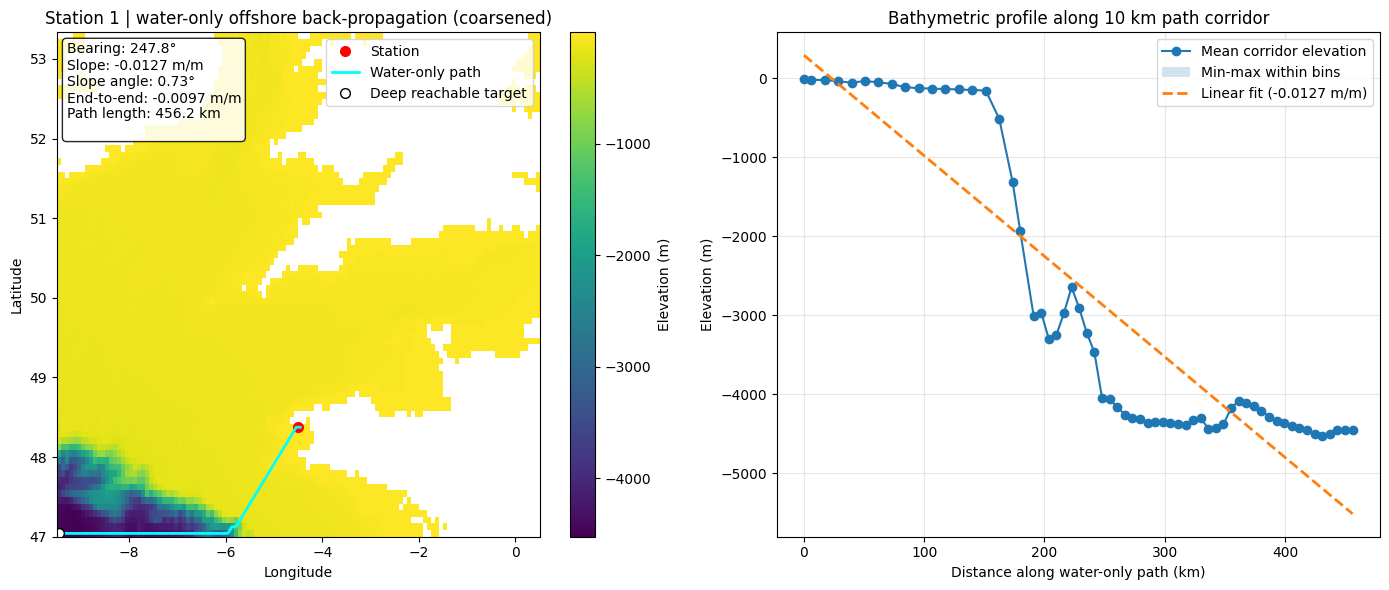

In [186]:
row = stats_df.iloc[0]
sid = row["station"]
slat = float(row["lat"])
slon = float(row["lon"])

tile = tile_lookup[(sid, "10x10")]

result, path_df, corridor_df, profile_df, water_mask, work_tile = offshore_water_only_direction_and_slope(
    tile,
    slat,
    slon,
    land_thresh=-0.5,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    bin_size_m=1000.0,
    depth_weight=2.0,
    distance_weight=1.0,
    endpoint_distance_reward=0.25,
    coarsen_before=True,
    target_n_points=10000
)

plot_water_only_offshore_path(
    work_tile,
    slat,
    slon,
    result,
    path_df,
    corridor_df,
    profile_df,
    title=f"Station {sid} | water-only offshore back-propagation (coarsened)"
)

In [183]:
row = stats_df.iloc[0]
sid = row["station"]
slat = float(row["lat"])
slon = float(row["lon"])

tile = tile_lookup[(sid, "0.1x0.1")]

result, path_df, corridor_df, profile_df, water_mask = offshore_water_only_direction_and_slope(
    tile,
    slat,
    slon,
    land_thresh=-0.5,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    bin_size_m=1000.0
)

plot_water_only_offshore_path(
    tile,
    slat,
    slon,
    result,
    path_df,
    corridor_df,
    profile_df,
    title=f"Station {sid} | water-only offshore back-propagation"
)

ValueError: too many values to unpack (expected 5)

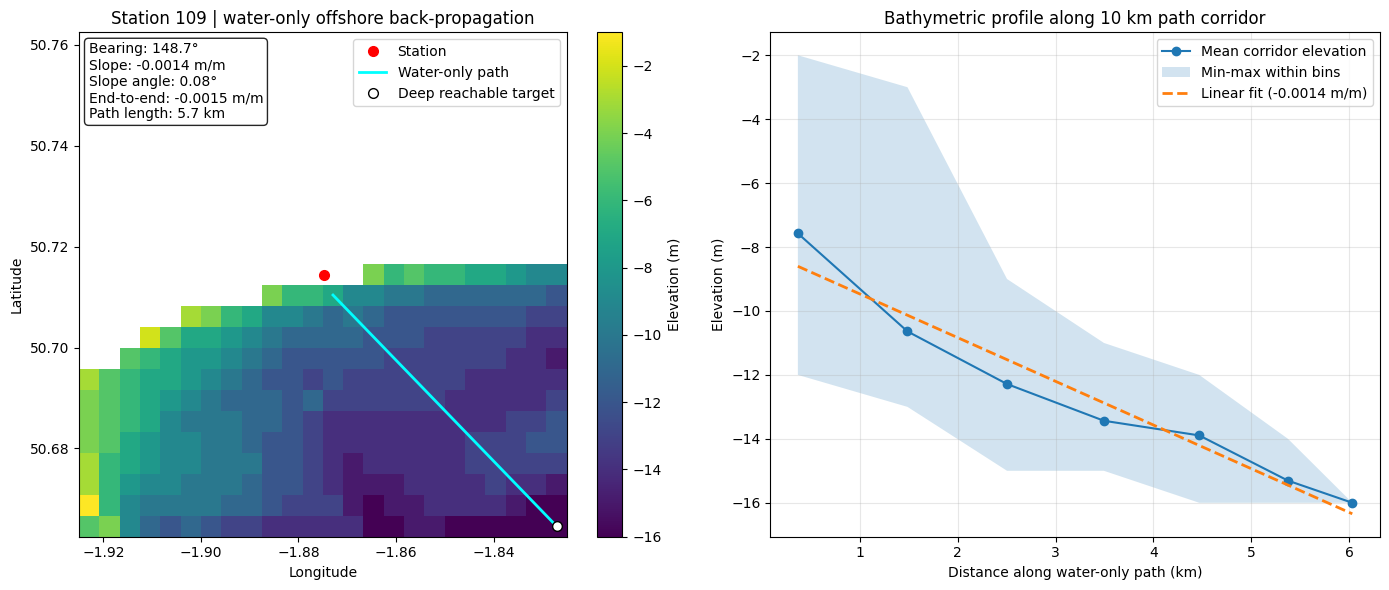

In [158]:
row = stats_df.iloc[2020]
sid = row["station"]
slat = float(row["lat"])
slon = float(row["lon"])

tile = tile_lookup[(sid, "0.1x0.1")]

result, path_df, corridor_df, profile_df, water_mask = offshore_water_only_direction_and_slope(
    tile,
    slat,
    slon,
    land_thresh=-0.5,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    bin_size_m=1000.0
)

plot_water_only_offshore_path(
    tile,
    slat,
    slon,
    result,
    path_df,
    corridor_df,
    profile_df,
    title=f"Station {sid} | water-only offshore back-propagation"
)

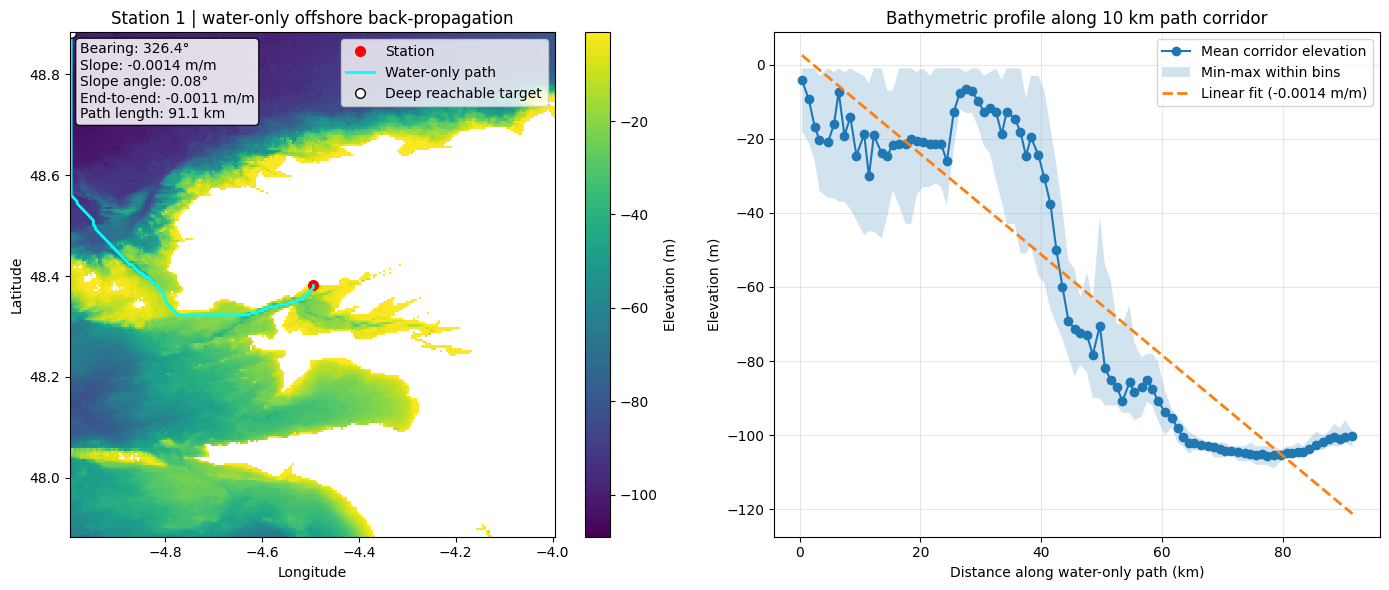

In [151]:
row = stats_df.iloc[0]
sid = row["station"]
slat = float(row["lat"])
slon = float(row["lon"])

tile = tile_lookup[(sid, "1x1")]

result, path_df, corridor_df, profile_df, water_mask = offshore_water_only_direction_and_slope(
    tile,
    slat,
    slon,
    land_thresh=-0.5,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    bin_size_m=1000.0
)

plot_water_only_offshore_path(
    tile,
    slat,
    slon,
    result,
    path_df,
    corridor_df,
    profile_df,
    title=f"Station {sid} | water-only offshore back-propagation"
)

In [11]:
stats_df.columns

Index(['Unnamed: 0', 'station', 'block_time', 'extract_time', 'u10', 'v10',
       'd2m', 't2m', 'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'tide',
       'residual', 'residual_is_deviant', 'wind_magnitude', 'wind_dir',
       'u10_abs', 'v10_abs', 'wind_wave_diff', 'wind_wave_alignment', 'tau_u',
       'tau_u_abs', 'tau_v', 'tau_v_abs', 'tau_mag', 'lat', 'lon',
       'wind_to_mean_deg', 'coastal_bearing_deg', 'coastal_radius_used_deg',
       'bay_bearing_deg', 'bay_radius_used_deg', 'coastal_vs_bay_diff_deg',
       'coastal_normal1_deg', 'coastal_normal2_deg',
       'wind_vs_coastal_normal_diff_deg', 'wind_more_coastalshore_deg',
       'bay_normal1_deg', 'bay_normal2_deg', 'wind_vs_bay_normal_diff_deg',
       'wind_more_bayshore_deg'],
      dtype='object')

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def unit_vec_from_bearing(bearing_deg):
    th = np.deg2rad(bearing_deg)
    return np.sin(th), np.cos(th)  # east, north

def plot_station_tile_with_vectors(
    station_id,
    size_key,
    results_by_var,
    summary_df,
    bathy_var="elevation",
    wind_col="wind_dir_mean",
    wave_col="mwd_mean",
    convert_wind_to_from=False,
    convert_wave_to_from=False,
    verbose=True,
):
    # summary row
    row = summary_df[
        (summary_df["station"] == station_id) &
        (summary_df["tile_size"] == size_key)
    ]

    if len(row) == 0:
        if verbose:
            print(f"Skipping station {station_id} ({size_key}): no summary row")
        return
    row = row.iloc[0]

    # tile lookup
    tile = None
    for ds_tile in results_by_var[bathy_var][size_key]:
        sid = ds_tile.coords.get("station_id", None)
        if sid is None:
            continue
        sid = sid.values
        sid = sid.item() if hasattr(sid, "item") else sid
        if sid == station_id:
            tile = ds_tile
            break

    if tile is None:
        if verbose:
            print(f"Skipping station {station_id} ({size_key}): no tile found")
        return

    # empty tile check
    if tile.sizes.get("lat", 0) == 0 or tile.sizes.get("lon", 0) == 0:
        if verbose:
            print(f"Skipping station {station_id} ({size_key}): empty tile")
        return

    # station coords
    slat = row.get("station_lat", np.nan)
    slon = row.get("station_lon", np.nan)
    if pd.isna(slat) or pd.isna(slon):
        if verbose:
            print(f"Skipping station {station_id} ({size_key}): missing station coordinates")
        return
    slat = float(slat)
    slon = float(slon)

    # direction values
    wind_dir = row[wind_col] if wind_col in row.index else np.nan
    wave_dir = row[wave_col] if wave_col in row.index else np.nan

    if pd.notna(wind_dir) and convert_wind_to_from:
        wind_dir = (float(wind_dir) + 180.0) % 360.0
    if pd.notna(wave_dir) and convert_wave_to_from:
        wave_dir = (float(wave_dir) + 180.0) % 360.0

    # bathymetry
    z = tile[bathy_var]
    if bathy_var == "elevation":
        z = z.where(z <= -0.5)

    # extent safely
    lon_vals = tile["lon"].values
    lat_vals = tile["lat"].values

    if lon_vals.size == 0 or lat_vals.size == 0:
        if verbose:
            print(f"Skipping station {station_id} ({size_key}): zero-size lon/lat array")
        return

    lon_min = float(np.nanmin(lon_vals))
    lon_max = float(np.nanmax(lon_vals))
    lat_min = float(np.nanmin(lat_vals))
    lat_max = float(np.nanmax(lat_vals))

    dlon = lon_max - lon_min
    dlat = lat_max - lat_min

    if dlon <= 0 or dlat <= 0:
        if verbose:
            print(f"Skipping station {station_id} ({size_key}): invalid extent")
        return

    # make arrows clearly visible
    L = 0.25 * min(dlon, dlat)

    fig, ax = plt.subplots(figsize=(8, 6))

    try:
        pcm = ax.pcolormesh(tile["lon"], tile["lat"], z, shading="auto")
        plt.colorbar(pcm, ax=ax, label=bathy_var)
    except Exception as e:
        if verbose:
            print(f"Skipping station {station_id} ({size_key}): plot failed: {e}")
        plt.close(fig)
        return

    # station
    ax.plot(slon, slat, "ro", ms=7, label="Station", zorder=5)

    plotted_any = False

    # wind arrow
    if pd.notna(wind_dir):
        ux, uy = unit_vec_from_bearing(float(wind_dir))
        ax.arrow(
            slon, slat,
            L * ux, L * uy,
            length_includes_head=True,
            head_width=0.04 * min(dlon, dlat),
            head_length=0.06 * min(dlon, dlat),
            linewidth=2,
            color="deepskyblue",
            zorder=6
        )
        ax.text(
            lon_min + 0.02 * dlon, lat_max - 0.08 * dlat,
            f"Wind: {float(wind_dir):.1f}°",
            color="deepskyblue", fontsize=10
        )
        plotted_any = True
    elif verbose:
        print(f"Station {station_id} ({size_key}): wind direction missing/NaN in {wind_col}")

    # wave arrow
    if pd.notna(wave_dir):
        ux, uy = unit_vec_from_bearing(float(wave_dir))
        ax.arrow(
            slon, slat,
            L * ux, L * uy,
            length_includes_head=True,
            head_width=0.04 * min(dlon, dlat),
            head_length=0.06 * min(dlon, dlat),
            linewidth=2,
            color="orange",
            zorder=6
        )
        ax.text(
            lon_min + 0.02 * dlon, lat_max - 0.15 * dlat,
            f"Wave: {float(wave_dir):.1f}°",
            color="orange", fontsize=10
        )
        plotted_any = True
    elif verbose:
        print(f"Station {station_id} ({size_key}): wave direction missing/NaN in {wave_col}")

    if verbose and not plotted_any:
        print(f"Station {station_id} ({size_key}): no vectors plotted")

    ax.set_title(f"Station {station_id} | tile {size_key}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [ ]:
stats_df.to_csv("DIff_GEV_station_variable_statistics.csv", index=False)